In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import re
from collections import Counter
from sklearn.model_selection import train_test_split

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

print("Using device:", device)

Using device: cuda


In [6]:
from tensorflow.keras.datasets import imdb as keras_imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB_SIZE = 10_000
MAX_LEN = 200

(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = keras_imdb.load_data(
    num_words=MAX_VOCAB_SIZE
)

# Combine train/test, then take 5000 samples total
x_all = np.concatenate([x_train_raw, x_test_raw])
y_all = np.concatenate([y_train_raw, y_test_raw])

np.random.seed(42)
sample_indices = np.random.choice(len(x_all), size=5000, replace=False)

x_sample = x_all[sample_indices]
y_sample = y_all[sample_indices]

# Pad/truncate reviews to length 200
x_sample = pad_sequences(
    x_sample,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post",
    value=0
)

# Train/val split
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x_sample,
    y_sample,
    test_size=0.2,
    random_state=42,
    stratify=y_sample
)

print("Train shape:", x_train.shape)
print("Val shape:", x_val.shape)
print("Example encoded review:")
print(x_train[0][:50])
print("Example label:", y_train[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


c:\Users\Baku\anaconda3\envs\torch_env\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Train shape: (4000, 200)
Val shape: (1000, 200)
Example encoded review:
[   1   13  296   14   20  103  319   12   23 2139   13  119    4 2139
  621    5   13  119    4   20   13  296    4   20   40   12   16   24
 2472    8    4 2139  123   13  244   35 7394 5571    5   28  110   51
  571    8   91 1151   54   36   26  679]
Example label: 1


In [7]:
class IMDBDataset(Dataset):
    def __init__(self, reviews, labels):
        self.reviews = reviews
        self.labels = labels

    def __len__(self):
        return len(self.reviews)

    def __getitem__(self, idx):
        x = torch.tensor(self.reviews[idx], dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y


train_dataset = IMDBDataset(x_train, y_train)
val_dataset = IMDBDataset(x_val, y_val)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

x_batch, y_batch = next(iter(train_loader))

print("x_batch shape:", x_batch.shape)
print("y_batch shape:", y_batch.shape)
print("First review token IDs:", x_batch[0][:30])
print("First label:", y_batch[0])

x_batch shape: torch.Size([32, 200])
y_batch shape: torch.Size([32])
First review token IDs: tensor([   1,   13,  482,   13,  244,  582,  522,    8,    4, 1073,   13,   43,
         219,   14, 5125,  310,    7, 5458, 5458,    2,   23, 1749,  248,   13,
         161,  124,   12, 3849,    5,   16])
First label: tensor(0.)


## Task 1

In [8]:
import math
import torch.nn.functional as F

In [9]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.size(-1)

    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

    if mask is not None:
        scores = scores.masked_fill(mask, float("-inf"))

    weights = torch.softmax(scores, dim=-1)

    output = torch.matmul(weights, V)

    return output, weights

In [10]:
torch.manual_seed(42)

batch_size = 2
seq_len = 4
d_k = 8

Q = torch.randn(batch_size, seq_len, d_k)
K = torch.randn(batch_size, seq_len, d_k)
V = torch.randn(batch_size, seq_len, d_k)

output, weights = scaled_dot_product_attention(Q, K, V)

print("Q shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)

print("\nAttention output shape:", output.shape)
print("Attention weights shape:", weights.shape)

Q shape: torch.Size([2, 4, 8])
K shape: torch.Size([2, 4, 8])
V shape: torch.Size([2, 4, 8])

Attention output shape: torch.Size([2, 4, 8])
Attention weights shape: torch.Size([2, 4, 4])


In [11]:
# Manual checks

row_sums = weights.sum(dim=-1)

print("Do softmax rows sum to 1?")
print(row_sums)

manual_output = torch.matmul(weights, V)

print("\nDoes output match weights @ V?")
print(torch.allclose(output, manual_output, atol=1e-6))

Do softmax rows sum to 1?
tensor([[1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000]])

Does output match weights @ V?
True


In [12]:
# Compare with PyTorch built-in scaled_dot_product_attention

builtin_output = F.scaled_dot_product_attention(
    Q,
    K,
    V,
    attn_mask=None,
    dropout_p=0.0,
    is_causal=False
)

print("Does our output match PyTorch built-in attention?")
print(torch.allclose(output, builtin_output, atol=1e-6))

Does our output match PyTorch built-in attention?
True


In [13]:
# Print attention weights for the first sequence in the batch

print("Attention weight matrix for first example:")
print(weights[0])

Attention weight matrix for first example:
tensor([[0.5092, 0.3165, 0.1113, 0.0631],
        [0.2619, 0.3828, 0.1773, 0.1779],
        [0.2445, 0.0241, 0.2013, 0.5302],
        [0.7451, 0.1075, 0.0349, 0.1124]])


### Comment on attention weights

The attention weight matrix has shape `(4, 4)` for one sequence.

Each row represents one query token.

Each column represents how much attention that query token pays to each key/value token in the sequence.

For example, row 0 shows how token 0 distributes its attention across tokens 0, 1, 2, and 3.

Each row sums to 1 because the scores are passed through softmax.

## Task 2

In [14]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, num_classes=2):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )

        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)

        lstm_out, (hidden, cell) = self.lstm(embedded)

        last_hidden = hidden[-1]

        dropped = self.dropout(last_hidden)
        logits = self.fc(dropped)

        return logits

In [15]:
vocab_size = MAX_VOCAB_SIZE

model = LSTMClassifier(
    vocab_size=vocab_size,
    embed_dim=64,
    hidden_dim=128,
    num_classes=2
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

model

LSTMClassifier(
  (embedding): Embedding(10000, 64, padding_idx=0)
  (lstm): LSTM(64, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)

In [16]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.long().to(device)

        optimizer.zero_grad()

        logits = model(x_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x_batch.size(0)

        predictions = torch.argmax(logits, dim=1)
        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy


def evaluate(model, val_loader, criterion, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.long().to(device)

            logits = model(x_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * x_batch.size(0)

            predictions = torch.argmax(logits, dim=1)
            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

In [17]:
num_epochs = 5

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

start_time = time.time()

best_val_acc = 0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    best_val_acc = max(best_val_acc, val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

end_time = time.time()
total_training_time = end_time - start_time

print("\nBest validation accuracy:", round(best_val_acc, 4))
print("Total training time:", round(total_training_time, 2), "seconds")

Epoch [1/5] Train Loss: 0.6938 | Train Acc: 0.5065 | Val Loss: 0.6910 | Val Acc: 0.5210
Epoch [2/5] Train Loss: 0.6803 | Train Acc: 0.5577 | Val Loss: 0.6960 | Val Acc: 0.5440
Epoch [3/5] Train Loss: 0.6924 | Train Acc: 0.5605 | Val Loss: 0.6919 | Val Acc: 0.5230
Epoch [4/5] Train Loss: 0.6542 | Train Acc: 0.5998 | Val Loss: 0.6855 | Val Acc: 0.5860
Epoch [5/5] Train Loss: 0.6317 | Train Acc: 0.6072 | Val Loss: 0.7211 | Val Acc: 0.5430

Best validation accuracy: 0.586
Total training time: 3.98 seconds


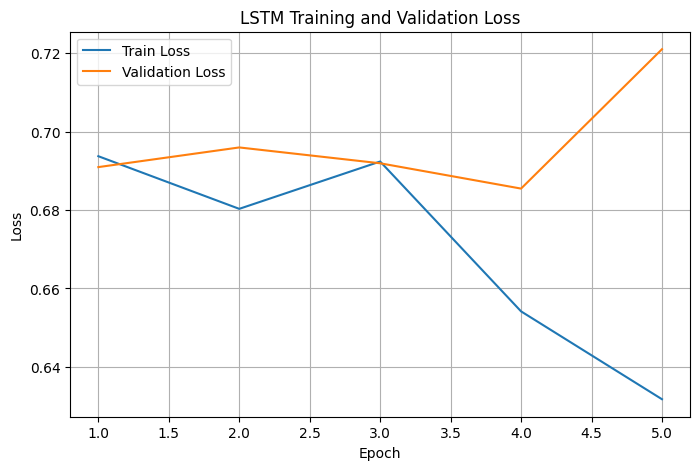

In [18]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

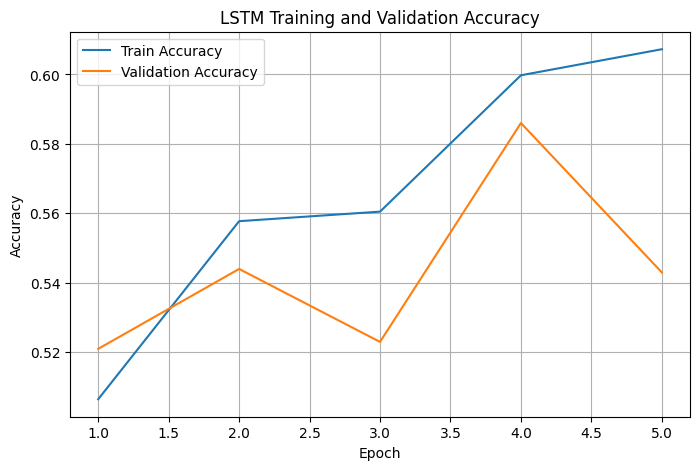

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Task 3

In [20]:
class TransformerClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        max_len=200,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        num_classes=2
    ):
        super().__init__()

        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.position_embedding = nn.Embedding(max_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=0.1,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        batch_size, seq_len = x.shape

        positions = torch.arange(seq_len, device=x.device)
        positions = positions.unsqueeze(0).expand(batch_size, seq_len)

        token_emb = self.token_embedding(x)
        pos_emb = self.position_embedding(positions)

        embedded = token_emb + pos_emb

        padding_mask = x == 0

        encoded = self.transformer_encoder(
            embedded,
            src_key_padding_mask=padding_mask
        )

        # We use mean pooling over the sequence dimension
        mask = (x != 0).unsqueeze(-1)
        encoded = encoded * mask

        summed = encoded.sum(dim=1)
        lengths = mask.sum(dim=1).clamp(min=1)

        pooled = summed / lengths

        dropped = self.dropout(pooled)
        logits = self.fc(dropped)

        return logits

In [21]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [22]:
transformer_model = TransformerClassifier(
    vocab_size=MAX_VOCAB_SIZE,
    max_len=MAX_LEN,
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    num_classes=2
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(transformer_model.parameters(), lr=1e-3)

print(transformer_model)
print("Transformer parameter count:", count_parameters(transformer_model))

TransformerClassifier(
  (token_embedding): Embedding(10000, 64, padding_idx=0)
  (position_embedding): Embedding(200, 64)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)
Transformer parameter count: 719874


In [23]:
num_epochs = 5

transformer_train_losses = []
transformer_val_losses = []
transformer_train_accuracies = []
transformer_val_accuracies = []

transformer_start_time = time.time()

transformer_best_val_acc = 0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        transformer_model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        transformer_model,
        val_loader,
        criterion,
        device
    )

    transformer_train_losses.append(train_loss)
    transformer_val_losses.append(val_loss)
    transformer_train_accuracies.append(train_acc)
    transformer_val_accuracies.append(val_acc)

    transformer_best_val_acc = max(transformer_best_val_acc, val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

transformer_end_time = time.time()
transformer_total_training_time = transformer_end_time - transformer_start_time

print("\nBest transformer validation accuracy:", round(transformer_best_val_acc, 4))
print("Transformer total training time:", round(transformer_total_training_time, 2), "seconds")

c:\Users\Baku\anaconda3\envs\torch_env\Lib\site-packages\torch\nn\modules\transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


Epoch [1/5] Train Loss: 0.6705 | Train Acc: 0.5807 | Val Loss: 0.5863 | Val Acc: 0.6840
Epoch [2/5] Train Loss: 0.5279 | Train Acc: 0.7322 | Val Loss: 0.5194 | Val Acc: 0.7410
Epoch [3/5] Train Loss: 0.4054 | Train Acc: 0.8150 | Val Loss: 0.5212 | Val Acc: 0.7560
Epoch [4/5] Train Loss: 0.2916 | Train Acc: 0.8750 | Val Loss: 0.5595 | Val Acc: 0.7700
Epoch [5/5] Train Loss: 0.1880 | Train Acc: 0.9315 | Val Loss: 0.6434 | Val Acc: 0.7690

Best transformer validation accuracy: 0.77
Transformer total training time: 12.33 seconds


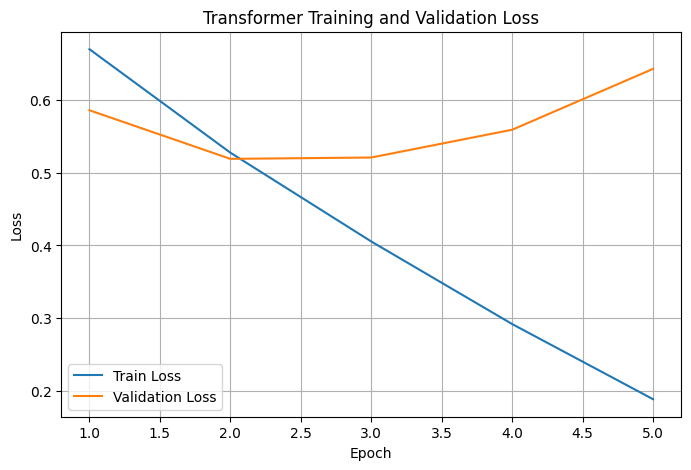

In [24]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, transformer_train_losses, label="Train Loss")
plt.plot(epochs, transformer_val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transformer Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

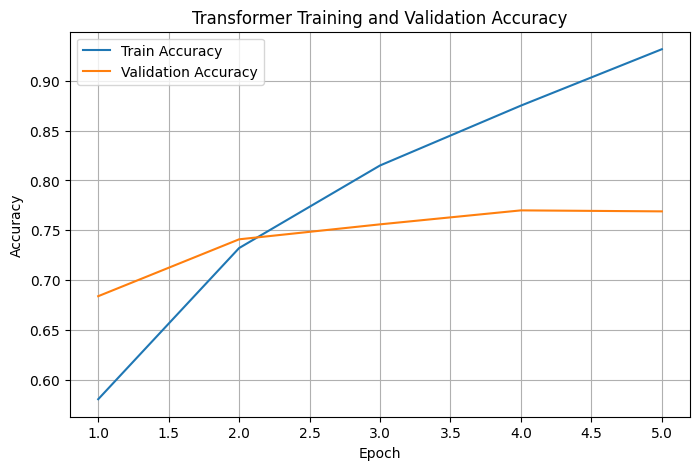

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, transformer_train_accuracies, label="Train Accuracy")
plt.plot(epochs, transformer_val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transformer Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
lstm_param_count = count_parameters(model)
transformer_param_count = count_parameters(transformer_model)

comparison_df = pd.DataFrame({
    "Model": ["LSTM (Task 2)", "Transformer (Task 3)"],
    "Best val accuracy": [
        round(best_val_acc, 4),
        round(transformer_best_val_acc, 4)
    ],
    "Total training time": [
        round(total_training_time, 2),
        round(transformer_total_training_time, 2)
    ],
    "Parameter count": [
        lstm_param_count,
        transformer_param_count
    ]
})

comparison_df

,Model,Best val accuracy,Total training time,Parameter count
0,LSTM (Task 2),0.586,3.98,739586
1,Transformer (Task 3),0.770,12.33,719874


### Comparison

The Transformer achieved a substantially higher validation accuracy than the LSTM on the IMDB sentiment classification task. The best validation accuracy increased from **58.6%** for the LSTM to **77.0%** for the Transformer, indicating that the self-attention mechanism was better at capturing the important relationships between words in the reviews. The LSTM trained much faster, requiring only **3.98 seconds** compared to **12.33 seconds** for the Transformer, so the transformer's improved performance came at the cost of increased computation time. Interestingly, both models had a very similar number of trainable parameters (739,586 for the LSTM versus 719,874 for the Transformer), meaning the performance difference is mainly due to the architecture rather than model size. On this hardware and dataset size, the transformer's theoretical parallelism did not translate into faster training; in fact, it was roughly three times slower per training run. Overall, the Transformer provided the best classification performance, while the LSTM offered significantly faster training.